importing valid solutions for use in scoring in the objective function

In [1]:
import sys
!{sys.executable} -m pip install numpy
!{sys.executable} -m pip install matplotlib

In [15]:
import numpy as np
import random

In [16]:
valid_words = []

file_path = 'small.txt'

with open(file_path, 'r') as file:
    for line in file:
        sline = line.strip()
        valid_words.append(sline)

print(len(valid_words))

7722


this is just a list of possible places in the grid that have potential to score. used in the objective function

In [17]:
lineSlotIndexes = [
	[0,  1,  2,  3,  4], 
	[5,  6,  7,  8,  9], 
	[10, 11, 12, 13, 14], 
	[15, 16, 17, 18, 19], 
	[20, 21, 22, 23, 24], 
	
	[0, 5, 10, 15, 20], 
	[1, 6, 11, 16, 21], 
	[2, 7, 12, 17, 22], 
	[3, 8, 13, 18, 23], 
	[4, 9, 14, 19, 24], 
	
	[0, 6, 12, 18, 24], 
	[5, 8, 12, 16, 20],
	
	[1, 7, 13, 19],
	[3, 7, 11, 15],
	[5, 11, 17, 23],
	[9, 13, 17, 21],
	
	[2, 6, 10],
	[2, 8, 14],
	[10, 16, 22],
	[14, 18, 22]
]

below is the objective function that takes in a solution (and an empty dict to output potential words) and returns a number representing the fitness of that solution. in this case, higher is better

In [18]:
def get_score(candidate, words = None) -> int:
	if (words == None):
		words = {}
	for line in lineSlotIndexes:
		l2 = line[2]
		c = candidate[l2]
			
		l0 = line[0]
		a = candidate[l0]
		l1 = line[1]
		b = candidate[l1]
		
		chunk : String = a+b+c
		check_chunk(chunk, [l0,l1,l2], words)
		
		if len(line) < 4:
			continue
		
		l3 = line[3]
		d = candidate[l3]
		
		chunk = b+c+d
		check_chunk(chunk, [l1,l2,l3], words)
		
		chunk = a+b+c+d
		check_chunk(chunk, [l0,l1,l2,l3], words)
		
		if len(line) < 5:
			continue
		
		l4 = line[4]
		e = candidate[l4]
		
		chunk = c+d+e
		check_chunk(chunk, [l2,l3,l4], words)
		
		chunk = b+c+d+e
		check_chunk(chunk, [l1,l2,l3,l4], words)
		
		chunk = a+b+c+d+e
		check_chunk(chunk, [l0,l1,l2,l3,l4], words)
	
	total = 0
	for word in words:
		total += get_points(word)
	
	return total

def check_chunk(chunk: str, indexes: [], words: {}):
	if chunk in valid_words:
		words[chunk] = indexes
	chunk = chunk[::-1]
	if chunk in valid_words:
		words[chunk] = indexes

def get_points(word) -> int:
    if len(word) == 3:
        return 1
    elif len(word) == 4:
        return 2
    else:
        return 3

this is a test to make sure the objective function is working - i know that this solution set gives a score of 94

In [19]:
test_letter_set = ["s","p","a","n","s","m","n","r","a","t","a","u","i","o","o","r","n","l","p","p","t","r","a","p","s"]

words = {}
score = get_score(test_letter_set, words)
print(score)

94


defining a move as being a series of swaps of two items in the solution

In [20]:
class Swap:
    def __init__(
        self,
        l: int,
        r: int
    ):
        self.l = l
        self.r = r
        
    def __str__(self):
        return f"Swap({self.l}, {self.r})"

    __repr__ = __str__


class Move(list):
    def get_inverse(self):
        inverse = self[::-1]
        return inverse

class Candidate(list):
    def __init__(self, *args):
        list.__init__(self, *args)
        self.move = 0
    
    def set_move(self, move):
        self.move = move

    def __hash__(self):
        letters = str(self)
        return hash(letters)+ self.move

def add_move_to_position(candidate: Candidate, move: Move) -> Candidate:
    c = candidate[::]
    for swap in move:
        c[swap.l], c[swap.r] = c[swap.r], c[swap.l]
    return c

testing basic move

In [21]:
test_letter_set = ["s","p","a","n","s","m","n","r","a","t","a","u","i","o","o","r","n","l","p","p","t","r","a","p","s"]
move = Move([Swap(0, 5), Swap(3,9)])

print("add_move_to_position test")
print(test_letter_set)
add_move_to_position(test_letter_set, move)
print(test_letter_set)

print()
print("inverse test")
print(move)
inverse = move.get_inverse()
print(inverse)

add_move_to_position test
['s', 'p', 'a', 'n', 's', 'm', 'n', 'r', 'a', 't', 'a', 'u', 'i', 'o', 'o', 'r', 'n', 'l', 'p', 'p', 't', 'r', 'a', 'p', 's']
['s', 'p', 'a', 'n', 's', 'm', 'n', 'r', 'a', 't', 'a', 'u', 'i', 'o', 'o', 'r', 'n', 'l', 'p', 'p', 't', 'r', 'a', 'p', 's']

inverse test
[Swap(0, 5), Swap(3, 9)]
[Swap(3, 9), Swap(0, 5)]


In [22]:
def cycle_sort(array):
    clone = array[::]
    swaps = []
    # loop through the array to find cycles to rotate
    # note that the last item will already be sorted after the first n-1 cycles
    for cycle_start in range(0, len(clone) - 1):
        item = clone[cycle_start]
        # Find where to put the item.
        pos = cycle_start
        for i in range(cycle_start + 1, len(clone)):
            if clone[i] < item:
                pos += 1
        
        # if the item is already there, this is not a cycle
        if pos == cycle_start:
            continue
        
        # otherwise, put the item there or right after any duplicates
        while item == clone[pos]:
            pos += 1
        
        clone[pos], item = item, clone[pos]
        swaps.append(Swap(cycle_start, pos))
        
        # rotate the rest of the cycle
        while pos != cycle_start:
            # Find where to put the item.
            pos = cycle_start
            
            for i in range(cycle_start + 1, len(clone)):
                if clone[i] < item:
                    pos += 1
            
            # put the item there or right after any duplicates
            while item == clone[pos]:
                pos += 1
            
            clone[pos], item = item, clone[pos]
            if (cycle_start != pos):
                swaps.append(Swap(cycle_start, pos))
    
    return swaps

In [23]:
def add_moves(m1: Move, m2: Move) -> Move:
    move = Move(m1)
    move.extend(m2)
    return move

a = Move([Swap(0, 5), Swap(3,9)])
b = Move([Swap(0, 3), Swap(3,7)])
print("add moves test")
print(add_moves(a, b))

add moves test
[Swap(0, 5), Swap(3, 9), Swap(0, 3), Swap(3, 7)]


In [24]:
c1 = [1, 7, 3, 9, 6, 8, 7]
c2 = [6, 7, 7, 9, 3, 8, 1]

def subtract_positions(c1, c2) -> Move:
    r1 = cycle_sort(c1)
    r2 = cycle_sort(c2)
    
    invr2 = Move(r2).get_inverse()
    a = add_moves(Move(r1), invr2)
    return a

print(subtract_positions(c1, c2))

[Swap(1, 3), Swap(1, 6), Swap(1, 4), Swap(1, 2), Swap(1, 4), Swap(0, 6), Swap(0, 3), Swap(0, 2)]


In [43]:
print("subtract_positions test")
c1 = [1, 7, 3, 9, 6, 8, 7]
c2 = [6, 7, 7, 9, 3, 8, 1]

result = subtract_positions(c1, c2)
print(result)
print(add_move_to_position([1, 7, 3, 9, 6, 8, 7], result))

t1 = test_letter_set[::]
t2 = test_letter_set[::]
random.shuffle(t2)
print(t1)
print(t2)
result2 = subtract_positions(t1, t2)
print(result2)
print(add_move_to_position(test_letter_set[::], result2))


subtract_positions test
[Swap(1, 3), Swap(1, 6), Swap(1, 4), Swap(1, 2), Swap(1, 4), Swap(0, 6), Swap(0, 3), Swap(0, 2)]
[6, 7, 7, 9, 3, 8, 1]
['s', 'p', 'a', 'n', 's', 'm', 'n', 'r', 'a', 't', 'a', 'u', 'i', 'o', 'o', 'r', 'n', 'l', 'p', 'p', 't', 'r', 'a', 'p', 's']
['o', 'a', 'n', 'n', 't', 't', 'r', 's', 'a', 'p', 'o', 'p', 's', 'p', 's', 'a', 'l', 'r', 'a', 'r', 'u', 'n', 'm', 'p', 'i']
[Swap(0, 19), Swap(0, 12), Swap(0, 4), Swap(0, 20), Swap(0, 22), Swap(1, 13), Swap(1, 10), Swap(3, 7), Swap(3, 16), Swap(3, 8), Swap(5, 6), Swap(5, 9), Swap(5, 23), Swap(5, 14), Swap(5, 11), Swap(5, 24), Swap(5, 21), Swap(5, 17), Swap(15, 18), Swap(3, 15), Swap(3, 9), Swap(2, 8), Swap(2, 21), Swap(2, 14), Swap(2, 23), Swap(2, 4), Swap(2, 24), Swap(2, 20), Swap(2, 7), Swap(0, 18), Swap(0, 6), Swap(0, 22), Swap(0, 5), Swap(0, 16), Swap(0, 19), Swap(0, 12), Swap(0, 11)]
['o', 'a', 'n', 'n', 't', 't', 'r', 's', 'a', 'p', 'o', 'p', 's', 'p', 's', 'a', 'l', 'r', 'a', 'r', 'u', 'n', 'm', 'p', 'i']


In [44]:
import math

def multiply_move_by_number(move: Move, c) -> Move:
    if (c == 0):
        return Move()
    if (c > 0 and c <= 1):
        length = len(move)
        floor = math.floor(length * c)
        truncated = move[:floor:]
        return truncated
    if (c < 0):
        inv = move.get_inverse()
        return multiply_move_by_number(inv, -c)
    mult = Move(move)
    for i in range(math.floor(c) - 1):
        mult = add_moves(mult, move)
    r = c - math.floor(c)
    mult = add_moves(mult, multiply_move_by_number(move, r))
    return mult

In [45]:
print("multiply moves by number tests")
c = Move([Swap(0, 5), Swap(3, 9), Swap(0, 3), Swap(3, 7)])
print(multiply_move_by_number(c, 0.7))
print(multiply_move_by_number(c, 0.8))

print(multiply_move_by_number(c, 0))

print(multiply_move_by_number(c, -1))

print(multiply_move_by_number(c, 3))
print(multiply_move_by_number(c, 2.5))

multiply moves by number tests
[Swap(0, 5), Swap(3, 9)]
[Swap(0, 5), Swap(3, 9), Swap(0, 3)]
[]
[Swap(3, 7), Swap(0, 3), Swap(3, 9), Swap(0, 5)]
[Swap(0, 5), Swap(3, 9), Swap(0, 3), Swap(3, 7), Swap(0, 5), Swap(3, 9), Swap(0, 3), Swap(3, 7), Swap(0, 5), Swap(3, 9), Swap(0, 3), Swap(3, 7)]
[Swap(0, 5), Swap(3, 9), Swap(0, 3), Swap(3, 7), Swap(0, 5), Swap(3, 9), Swap(0, 3), Swap(3, 7), Swap(0, 5), Swap(3, 9)]


In [46]:
def distance_between(c1: Candidate, c2: Candidate):
    diff = subtract_positions(c1, c2)
    return len(diff)

In [47]:
print("distance between test")
print(distance_between(c1, c2))

distance between test
8


In [52]:
class Particle:
    def __init__(
        self,
        current: Candidate,
        velocity: Move,
        trust_self: float = 1.5,
        trust_history: float = 0.5,
        trust_neighbour: float = 0.5
        
    ):
        self.current = current
        self.velocity = velocity
        self.trust_self = trust_self
        self.trust_history = trust_history
        self.trust_neighbour = trust_neighbour

        self.move = 0

        self.history = {}
        cloneCurrent = Candidate(self.current)
        self.history[cloneCurrent] = get_score(self.current)
        self.best = cloneCurrent

    def do_move(self, neighbour_best: Candidate):
        self.neighbour_best = neighbour_best
        self.calculate_new_velocity()
        self.current = add_move_to_position(self.current, self.velocity)
        score = get_score(self.current)
        
        clone = Candidate(self.current)
        clone.set_move(self.move)
        self.move += 1
        
        self.history[clone] = score
        if (score > self.history[self.best]):
            self.best = clone

    def calculate_new_velocity(self):
        self_component = multiply_move_by_number(self.velocity, self.trust_self)
        diff_best = subtract_positions(self.current, self.best)
        history_component = multiply_move_by_number(diff_best, self.trust_history)
        diff_neighbour = subtract_positions(self.current, self.neighbour_best)
        neighbour_component = multiply_move_by_number(diff_neighbour, self.trust_neighbour)
        self.velocity = add_moves(add_moves(self_component, history_component), neighbour_component)

    def get_best_score(self):
        return self.history[self.best]

In [53]:
import random
from concurrent.futures import ThreadPoolExecutor

class Optimiser:
    def __init__(
        self,
        particle_count,
        turn_count,
        letter_set: Candidate
    ):
        self.particle_count = particle_count
        self.turn_count = turn_count
        self.letter_set = letter_set
        self.particles = []
        self.best_history = {}
        self.did_improve_last_turn = True

    def setup(self):
        letter_count = len(self.letter_set)
        
        for i in range(self.particle_count):
            if ((i % math.floor(self.particle_count/5)) == 0):
                print(f"\t particle {i}")
            particle_candidate = Candidate(self.letter_set)
            random.shuffle(particle_candidate)
            trust_self = 10
            trust_history = random.random() * 2 +7
            trust_neighbour = random.random()*8 + 5

            velocity_length = random.randint(10, 20)
            particle_velocity = Move()
            for i in range(velocity_length):
                a = random.randint(0, letter_count - 2)
                b = random.randint(0, letter_count - 2)
                if (a > b):
                    a += 1
                else:
                    b += 1
            
            p = Particle(particle_candidate, particle_velocity, trust_self, trust_history, trust_neighbour)
            self.particles.append(p)

    def update_best(self, i) -> Candidate:
        bestScore = 0
        bestCandidate = Candidate()
        for p in self.particles:
            pScore = p.get_best_score()
            if (pScore > bestScore):
                bestScore = pScore
                bestCandidate = p.best
        self.best_history[i] = (bestCandidate, bestScore)
        return bestCandidate

    def do_turn(self, i):
        prev_best_score = 0
        if (len(self.best_history) > 3):
            prev_best_score = self.best_history[list(self.best_history.keys())[-2]][1]
        neighbour_best = self.update_best(i)
        new_best_score = self.best_history[list(self.best_history.keys())[-1]][1]
        print(f"turn {i} prev_best_score: {prev_best_score}, new_best_score: {new_best_score}")

        self.did_improve_last_turn = new_best_score > prev_best_score
        
        x = 0
        # Create a thread pool with 2 workers
        with ThreadPoolExecutor(max_workers=16) as executor:
            for p in self.particles:
                executor.submit(p.do_move(neighbour_best), x % 16)
                if ((x % math.floor(self.particle_count/5)) == 0):
                    print(f"\t particle {x}")
                x += 1

    def run(self):
        for i in range(self.turn_count):
            print("turn " + str(i))
            self.do_turn(i)
            if not self.did_improve_last_turn:
                print("breaking")
                break;

    def get_best_result_index(self):
        bestCandidate = None
        bestScore = 0
        bestIndex = 0
        for h in self.best_history:
            if (bestScore < self.best_history[h][1]):
                bestCandidate = self.best_history[h][0]
                bestScore = self.best_history[h][1]
                bestIndex = h
        return bestIndex

In [55]:
import matplotlib.pyplot as plt

particle_count = 10000
turn_count = 1
letter_set = Candidate(test_letter_set)

print("setting up")

optimiser = Optimiser(particle_count, turn_count, letter_set)

optimiser.setup()

print("setup complete")

optimiser.run()

print("done :)")

setting up
	 particle 0
	 particle 2000
	 particle 4000
	 particle 6000
	 particle 8000
setup complete
turn 0
turn 0 prev_best_score: 0, new_best_score: 42
	 particle 0
	 particle 2000
	 particle 4000
	 particle 6000
	 particle 8000
done :)


overall best score: 42, result: ['a', 'n', 's', 'n', 'p', 's', 't', 'o', 'l', 'p', 'p', 't', 'a', 'o', 'a', 'u', 'i', 'a', 'p', 'r', 'r', 'm', 'n', 'r', 's']


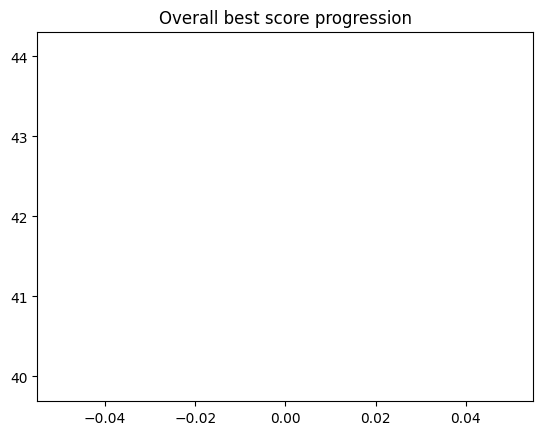

{'lot': [6, 7, 8], 'lots': [5, 6, 7, 8], 'plot': [6, 7, 8, 9], 'plots': [5, 6, 7, 8, 9], 'oat': [11, 12, 13], 'asp': [0, 5, 10], 'ups': [5, 10, 15], 'spur': [5, 10, 15, 20], 'mitt': [6, 11, 16, 21], 'lop': [8, 13, 18], 'pol': [8, 13, 18], 'app': [4, 9, 14], 'par': [9, 14, 19], 'rap': [9, 14, 19], 'pars': [9, 14, 19, 24], 'tap': [6, 12, 18], 'pat': [6, 12, 18], 'spa': [12, 18, 24], 'taps': [6, 12, 18, 24], 'spat': [6, 12, 18, 24], 'air': [12, 16, 20], 'lair': [8, 12, 16, 20], 'not': [3, 7, 11], 'ton': [3, 7, 11], 'tar': [11, 17, 23], 'rat': [11, 17, 23], 'star': [5, 11, 17, 23], 'rats': [5, 11, 17, 23], 'pin': [10, 16, 22], 'nip': [10, 16, 22]}


In [56]:
best_result_index = optimiser.get_best_result_index()
best_result = optimiser.best_history[best_result_index]
print(f"overall best score: {best_result[1]}, result: {best_result[0]}") 

turns = range(turn_count)
turnsWithFinal = range(turn_count + 1)
neighbour_bests = optimiser.best_history.values()
neighbour_best_scores = []
for n in neighbour_bests:
    neighbour_best_scores.append(n[1])
plt.plot(range(len(neighbour_best_scores)), neighbour_best_scores)
plt.title("Overall best score progression")
plt.show()

words = {}
get_score(best_result[0], words)
print(words)

PARTICLE 0 --------------
PARTICLE 1 --------------
PARTICLE 2 --------------
PARTICLE 3 --------------
PARTICLE 4 --------------
PARTICLE 5 --------------
PARTICLE 6 --------------
PARTICLE 7 --------------
PARTICLE 8 --------------
PARTICLE 9 --------------
PARTICLE 10 --------------
PARTICLE 11 --------------
PARTICLE 12 --------------
PARTICLE 13 --------------
PARTICLE 14 --------------
PARTICLE 15 --------------
PARTICLE 16 --------------
PARTICLE 17 --------------
PARTICLE 18 --------------
PARTICLE 19 --------------
PARTICLE 20 --------------
PARTICLE 21 --------------
PARTICLE 22 --------------
PARTICLE 23 --------------
PARTICLE 24 --------------
PARTICLE 25 --------------
PARTICLE 26 --------------
PARTICLE 27 --------------
PARTICLE 28 --------------
PARTICLE 29 --------------
PARTICLE 30 --------------
PARTICLE 31 --------------
PARTICLE 32 --------------
PARTICLE 33 --------------
PARTICLE 34 --------------
PARTICLE 35 --------------
PARTICLE 36 --------------
PARTICLE 37

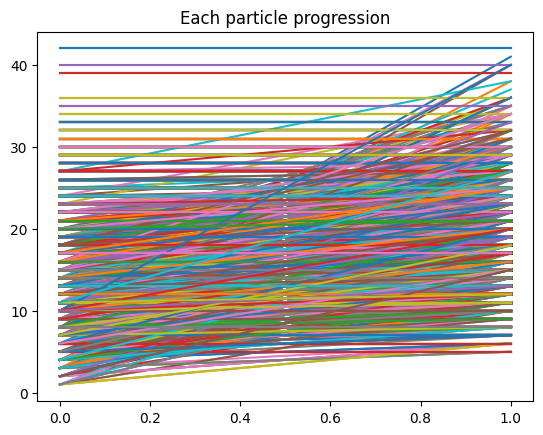

In [57]:
plt.figure()
i = 0
for p in optimiser.particles:
    #coefficients = np.polyfit(t, p.history.values()[::], 1)
    #slope, intercept = coefficients
    #best_fit_line = slope * months + intercept
    #plt.plot(t, best_fit_line, label=str(i))
    print(f"PARTICLE {i} --------------")
    bests = []
    best = 0
    for h in p.history:
        #print(f"{p.history[h]}, {best}")
        if (p.history[h] > best):
            best = p.history[h]
        bests.append(best)
    
    t = None
    if (len(bests) == turn_count):
        t = turns
    else:
        t = turnsWithFinal
    
    plt.plot(t, bests, label=str(i))
    i += 1
plt.title("Each particle progression")
plt.show()

In [58]:
initials = []
finals = []
for p in optimiser.particles:
    initials.append(next(iter(p.history.keys())))
    finals.append(p.current)

total_initial_distance = 0
initial_distance_count = 0
for i in range(len(initials)):
    if ((i % 50) == 0):
        print(i)
    for j in range(len(initials)):
        if (i == j):
            continue
        diff = subtract_positions(initials[i], initials[j])
        total_initial_distance += len(diff)
        initial_distance_count += 1

print(total_initial_distance)
print(initial_distance_count)
print((total_initial_distance * 1.0) / (initial_distance_count * 1.0))



0


KeyboardInterrupt: 

In [ ]:
total_final_distance = 0
final_distance_count = 0
for i in range(len(finals)):
    if ((i % 50) == 0):
        print(i)
    for j in range(len(finals)):
        if (i == j):
            continue
        diff = subtract_positions(finals[i], finals[j])
        total_final_distance += len(diff)
        final_distance_count += 1

print(total_final_distance)
print(final_distance_count)
print((total_final_distance * 1.0) / (final_distance_count * 1.0))



ValueError: x and y must have same first dimension, but have shapes (51,) and (10,)

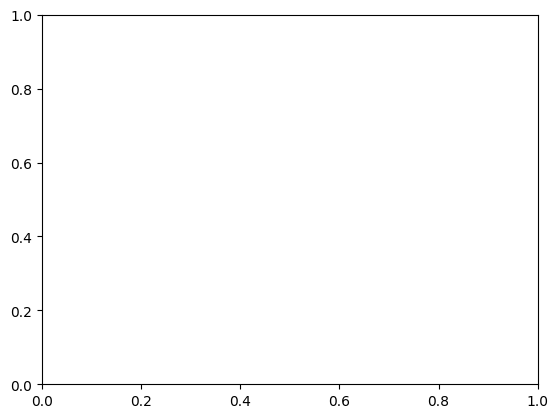

In [36]:

plt.figure()
i = 0
for p in optimiser.particles:
    t = None
    if (len(p.history.values()) == turn_count):
        t = turns
    else:
        t = turnsWithFinal
        
    #coefficients = np.polyfit(t, p.history.values()[::], 1)
    #slope, intercept = coefficients
    #best_fit_line = slope * months + intercept
    #plt.plot(t, best_fit_line, label=str(i))
    
    plt.plot(t, p.history.values(), label=str(i))
    i += 1
plt.title("Each particle progression")
plt.show()

In [ ]:
for i in range(len(optimiser.particles)):
    p = optimiser.particles[i]
    print(f"\n---Particle {i}---")
    print(f"velocity at end: {p.velocity}\ntrust_self: {p.trust_self}\ntrust_history: {p.trust_history}\ntrust_neighbour: {p.trust_neighbour}")
    print(f"\nfinal state: {p.current}")

In [208]:
for i in range(len(optimiser.particles)):
    p = optimiser.particles[i]
    print(f"\n\n---Particle {i}---")
    for h in p.history:
        print(f"score: {p.history[h]}; candidate: {h}")



---Particle 0---
score: 13; candidate: ['n', 'u', 'o', 'r', 'o', 'n', 't', 'p', 'l', 's', 'm', 'a', 's', 'a', 'a', 'p', 't', 'p', 'i', 'a', 's', 'p', 'r', 'n', 'r']
score: 27; candidate: ['s', 'p', 'm', 'a', 'i', 'l', 'o', 'a', 'n', 'n', 'a', 'o', 'n', 'r', 'p', 'p', 'u', 't', 'r', 'p', 's', 's', 'r', 't', 'a']
score: 15; candidate: ['a', 'r', 'a', 'a', 'i', 'l', 'm', 'n', 'n', 'n', 'o', 'o', 'p', 'p', 'p', 'p', 'u', 'r', 'r', 's', 's', 's', 't', 't', 'a']
score: 10; candidate: ['p', 'a', 'o', 'a', 'i', 'l', 'a', 's', 'n', 'n', 'm', 'o', 'a', 't', 'p', 'p', 'r', 'u', 'r', 'n', 's', 's', 'r', 't', 'p']
score: 13; candidate: ['p', 'a', 'm', 'a', 'i', 'n', 'o', 's', 't', 'n', 'l', 'o', 'a', 't', 'p', 'p', 'r', 'p', 'r', 'n', 's', 's', 'r', 'a', 'u']
score: 23; candidate: ['p', 'r', 'n', 'a', 'i', 'l', 'u', 'o', 's', 'n', 'n', 'o', 't', 'a', 'p', 'p', 'a', 'r', 'r', 'm', 's', 's', 'a', 'p', 't']
score: 8; candidate: ['p', 'u', 'm', 'a', 'i', 'n', 'n', 'r', 'a', 'n', 't', 'o', 'a', 'a', '